- - -

<div class='alert alert-block alert-info' align=center><span style='font-size: xx-large; font-weight: bold'>LangChain: A Quick Walkthrough</span><br/><span style='font-size: large; font-weight: normal'>Models, Messages, Invoking, Streaming, Tools, and Agents</span><br/><br/><br/><span style='font-size: x-large; font-weight: bold;'>박 진 수</span><span style='font-size: medium; font-weight: normal'> 교수<br/>Intelligent Data Semantics Lab<br/>Seoul National University</span></div>

<!--
<span style='color: tomato;'>LangChain: A Quick Walkthrough</span>
===

<span style='font-size:125%;'>Models, Messages, Invoking, Streaming, Tools, and Agents</span>

* * *

<span style='font-size:125%; font-weight: bold;'>박 진 수</span> 교수  
Intelligent Data Semantics Lab  
Seoul National University

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

<font size=6 color='tomato'>LangChain: A Quick Walkthrough</font>   
<font size=5 color='forestgreen'>Models, Messages, Invoking, Streaming, Tools, and Agents</font>

* * *

**<font size=4>박 진 수</font>** 교수  
Intelligent Data Semantics Lab  
Seoul National University
-->

- - -

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span></li><li><span><a href="#모델---메시지---출력/스트리밍" data-toc-modified-id="모델---메시지---출력/스트리밍-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>모델 - 메시지 - 출력/스트리밍</a></span><ul class="toc-item"><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#메시지" data-toc-modified-id="메시지-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>메시지</a></span></li><li><span><a href="#메시지-호출" data-toc-modified-id="메시지-호출-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>메시지 호출</a></span></li><li><span><a href="#메시지-스트리밍" data-toc-modified-id="메시지-스트리밍-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>메시지 스트리밍</a></span></li></ul></li><li><span><a href="#외부-데이터(지식)-사용" data-toc-modified-id="외부-데이터(지식)-사용-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>외부 데이터(지식) 사용</a></span></li><li><span><a href="#에이전트" data-toc-modified-id="에이전트-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>에이전트</a></span><ul class="toc-item"><li><span><a href="#도구-정의" data-toc-modified-id="도구-정의-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>도구 정의</a></span></li><li><span><a href="#모델-초기화" data-toc-modified-id="모델-초기화-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>모델 초기화</a></span></li><li><span><a href="#실행" data-toc-modified-id="실행-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>실행</a></span></li></ul></li><li><span><a href="#기본-제공-에이전트(Built-in-Agent)" data-toc-modified-id="기본-제공-에이전트(Built-in-Agent)-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>기본 제공 에이전트(Built-in Agent)</a></span></li><li><span><a href="#Lab:-현재-디렉토리-파일-목록-도구를-가진-에이전트-만들기" data-toc-modified-id="Lab:-현재-디렉토리-파일-목록-도구를-가진-에이전트-만들기-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Lab: 현재 디렉토리 파일 목록 도구를 가진 에이전트 만들기</a></span></li></ul></div>

# 패키지 설치 및 API 설정

In [ ]:
!python -m pip install -qU python-dotenv beautifulsoup4 wikipedia langchain langchain-community  # YOUR LLM package HERE (e.g., ollama 'langchain[ollama]' mistralai 'langchain[mistralai]' groq 'langchain[groq]' google-genai 'langchain[google-genai]' anthropic 'langchain[anthropic]' openai 'langchain[openai]')
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 (API Key 명칭 수정 후 사용) - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [ ]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

# 모델 - 메시지 - 출력/스트리밍

## 모델 초기화

- - -
LangChain에서 사용할 수 있는 모델 이름과 형식은 공식 문서에서 확인할 수 있다.
- https://docs.langchain.com/oss/python/integrations/chat
- https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- - -

In [2]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# 모델을 바꿔 테스트하려면 init_chat_model을 사용한다.
model = init_chat_model(
    model='openai:gpt-5.4-mini'
)     
google = init_chat_model(
    model='google_genai:gemini-flash-latest' 
)
anthropic = init_chat_model(
    model='anthropic:claude-haiku-4-5', 
    thinking={
        'type': 'enabled', 
        'budget_tokens': 1024
    }, 
    max_tokens=2048
)  

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

## 메시지

In [3]:
# OpenAI 메시지 스타일
model.invoke([{'role': 'user', 'content': '대한민국의 수도는 어디입니까?'}]) 

AIMessage(content='대한민국의 수도는 서울특별시(서울)입니다. 서울은 정치·행정·경제·문화의 중심지입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 15, 'total_tokens': 181, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5gQIkXHgh1kWOL36YvBQIKTjvXL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7776-3909-75f1-b195-e2c6b391b2c1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 166, 'total_tokens': 181, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 128}})

In [4]:
# OpenAI 메시지 스타일
google.invoke([{'role': 'user', 'content': '대한민국의 수도는 어디입니까?'}])  

AIMessage(content=[{'type': 'text', 'text': '대한민국의 수도는 **서울**입니다.', 'extras': {'signature': 'EowDCokDAb4+9vtCM/RpFqZjHL1ky69PkSgBwckxCp+vB3z3RoFHzF38E2JVPmqZj2IwMwqdPMrmQaDLeA+glsNJ4/96Shr77WAMiuyVAMq0nLLLqjTINiAgG8e02oYA7WYNNAqrvCdVdnHBVpif9M79pIdRaoarQy1Ie2EUAOUFaml8fF+/rhyDeoZHv5nbjz0BTLvLpjeCn3cUCpopQpjg/uxyvuVnOOcXbIRcihP+xZkFyhmigAYRAGMg3qE6IU5VIht4uyeyD+7hkI604wuiRN832V58VL5QYzmix+8YaPxEhw4SmBGGmEOm9l4lDlrrKZgGTvOcfU/W5XfDE5P/8lLbuF6CqXBtr8+8MahTLqavMYxHgTH0ax6ioh7ExG5SqTLwmQKgwuMtK/K/ClpAg6woEaJ4NDgPMYumQnh1avCR69vBRirfM+yZ7JOHxXGA8YAE73eBfhplOCbC7+Gw7zh2dEtxZcIOIpGQtHi1RsbQv0XoY0hMjWui6DfnGnJOk5qLRfs7ZKXvoACJ'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d7776-4818-7bb1-8747-5d1a873fab83-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 95, 'total_tokens': 105, 'input_token_details': {'cache_read':

In [5]:
# OpenAI 메시지 스타일
anthropic.invoke([{'role': 'user', 'content': '대한민국의 수도는 어디입니까?'}]) 

AIMessage(content=[{'signature': 'EpsCCmMIDBgCKkA+Xhtk5yKkg21CCRdpTjMX533Df2YuaLMzbTISMRFccrOcjvrpZ/qO8S2HLYRn+PuPR7HfjLZbsgA/khXouOlfMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDF7UdtXflQ0YOb86+BoMCg0jJGSYforNxvn+IjCvKc7SwHa4ZMcc8sB9N3FqxxQJDy97YIJ5hJ7jRDDWoaCO38JsoiVGxrGC9AA7bTgqZiSr3KZTVB0khc985AYTVnp8Cyrx1Oo5gqKa4BvnpgIqooX6+xlwDp8frFndYf1Zr95llOLwmHX5U8/WqmYOXRLbPe6ecX7IbR4KM8NfW9jVDC4K89tSJpX+INONcLU7LMCswl0wNxgB', 'thinking': '이것은 간단한 사실 질문입니다. 대한민국의 수도는 서울입니다.', 'type': 'thinking'}, {'text': '대한민국의 수도는 **서울**입니다. 서울은 한반도의 중부에 위치하고 있으며, 정치, 경제, 문화의 중심지입니다.', 'type': 'text'}], additional_kwargs={}, response_metadata={'id': 'msg_01MfJJkjKpe4DQH4suamA3q1', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 53, 'output_tokens': 106, 'server_tool_

In [6]:
# 튜플 스타일
model.invoke(('user', '대한민국의 수도는 어디입니까?')) 

AIMessage(content='대한민국의 수도는 서울특별시(서울)입니다. 다만 일부 중앙행정기관은 세종특별자치시로 이전되어 정부 기능이 분산되어 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 369, 'prompt_tokens': 20, 'total_tokens': 389, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5gYejQuBxvTKYlM3HR3z18bRIDm', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7776-5407-7c90-a840-ff47716f2918-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 369, 'total_tokens': 389, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 320}})

In [7]:
# LangChain 스타일
from langchain.messages import HumanMessage
model.invoke([HumanMessage('대한민국의 수도는 어디입니까?')]) 

AIMessage(content='대한민국의 수도는 서울특별시(서울)입니다. 다만 일부 행정 기능과 부처들이 세종특별자치시로 이전해 정부 기능이 분산되어 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 243, 'prompt_tokens': 15, 'total_tokens': 258, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5ghO4WNeqJ29zPpdaArwLZQMdvT', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7776-7b9f-7b63-b4fc-a9e2299f40af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 243, 'total_tokens': 258, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 192}})

In [8]:
# 초간단 스타일
model.invoke('대한민국의 수도는 어디입니까?')

AIMessage(content='대한민국의 수도는 서울특별시(서울)입니다. 다만 일부 행정 기능은 세종특별자치시로 이전되어 세종은 행정중심도시 역할을 하고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 246, 'prompt_tokens': 15, 'total_tokens': 261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5gyl58aASGy3XIRURxNSCa5HI5J', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7776-bdeb-7071-a04f-5267482f981f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 246, 'total_tokens': 261, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 192}})

In [9]:
# OpenAI 메시지 스타일
model.invoke([  
    {'role': 'system', 'content': '사용자가 제공한 문장을 영어로 번역하세요.'},
    {'role': 'user', 'content': '좋은 아침입니다.'}    
])

AIMessage(content='Good morning.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 28, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5hKdbqaW8pZHTTueO4FBOCKVu4q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7777-0f77-7cd0-91e9-f7d2c4f859e7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 76, 'total_tokens': 104, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [10]:
# 튜플 스타일
model.invoke([  
    ('system', '사용자가 제공한 문장을 영어로 번역하세요.'),
    ('user', '좋은 아침입니다.')    
])

AIMessage(content='Good morning.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 28, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5hLhGEGLHyxuHwlRIJC40bZ2TLq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7777-1aa3-72f3-8b19-8bd145799adf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 76, 'total_tokens': 104, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

In [11]:
# LangChain 스타일
from langchain.messages import SystemMessage, HumanMessage

model.invoke([  
    SystemMessage('사용자가 제공한 문장을 영어로 번역하세요.'),
    HumanMessage('좋은 아침입니다.'),    
])

AIMessage(content='Good morning.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 28, 'total_tokens': 104, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5hOFbxy2PkY9cMOmQDz9tLh6UNY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7777-22ea-7d53-8b6f-fe479fbae981-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 76, 'total_tokens': 104, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 64}})

## 메시지 호출

In [12]:
result = model.invoke('대한민국의 수도는 어딘가요?')
result_google = google.invoke('대한민국의 수도는 어딘가요?')
result_anthropic = anthropic.invoke('대한민국의 수도는 어딘가요?')

result

AIMessage(content='대한민국의 수도는 서울특별시(서울)입니다. 한강을 중심으로 한 정치·행정·경제·문화의 중심지입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 170, 'prompt_tokens': 17, 'total_tokens': 187, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5hR0ROC9Uki3M35i9txNb9cr4R3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d7777-3110-7332-a9e5-7c650715f46a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 170, 'total_tokens': 187, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 128}})

In [13]:
result_google

AIMessage(content=[{'type': 'text', 'text': '대한민국의 수도는 **서울**입니다.', 'extras': {'signature': 'EqMDCqADAb4+9vtPrM8qAJvmCefqkfh3QrQlUBuOoofOfb3HY4rNTxUGUGpZgJEpVK3ZFdIcD1enfE0i9lwS6wcNi8mKULXW+WEPN+Rl4B2RB/ArgIBf4/iVjJ7f+reZcTxlrWKf0oaJXsbwJv98BgjnTYvBiQiGTJ95QJsAWhx+atQl1MbByFHOuaPDrb8Csn38UFHVOqKWiQp6oXswN3z6wRsHjXEQGhEz3/+emuLXMDsrJZOx6SjTE3Jsy9M4a6F8KM/R+KVocqxn4jkqe9L50sSVkF+eY//B2UpD/tFGugtcbGwD+LypnKm6Xzz2eiiju2bwZToxSJgw7Sn8I/ami4C5+rNDRt9tl1jM8bsOmM/y9Tcyk4LPUX6qSKmgQoODnqAzRj9KaA+Xw7dOKRkuNtNvQ3T1chIsofQGnoJY2sXVbTnWU3jVyvcKDWqnZW0yO13sMc+3h0ya4FZYy4Fa7RSgRipgdOEgp1UajlUnVNhiro8k59kGsT4IlmG/YRP4xq571C/tdplMeBE4LGbLqB7oigZHkw4nhqa9aLkdk17hySI='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3-flash-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d7777-408e-7602-9ad2-f554872fff8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 100, 'total_tokens': 111, 'inp

In [14]:
result_anthropic

AIMessage(content=[{'signature': 'EtACCmMIDBgCKkBN+iEwPVlYk9HwwwGOo93ijMghb5GRrect5UtRLesUA8oDNjdwO4F/8JeG/GBJ6NbqurD5S62auP3He8OpIDeKMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDKoIe0F6wKE7q8t+ihoMCjZlyWZ/fNSut6HRIjDr65n0mIjddBgeiLv+sBznaIk8WQ3v1rl1HsQwQwwuWifxTff7Vw+yYSE+/kDbj+8qmgHl5+OGp3CUcVgATXZ1QQ/RlaT6LNyQe32a1XVsgcMsFPHif+oYiHEkRFjb2umD0UA37ocmfM0IFwAKm1dFwYWYbPblERSWJr3zDJY6VXDBfbEdlTVmLAwLfj3yJ1bBQ2jNFxCOyDoEKMQuOy/k0PvspAkJGedXYfvOLAKm5rPnlwOD7ynyZqg3ieJrwhQ1tQpPiZVPAIue/R1HGAE=', 'thinking': 'This is a straightforward factual question in Korean asking "What is the capital of South Korea?"\n\nThe answer is Seoul (서울 in Korean).', 'type': 'thinking'}, {'text': '대한민국의 수도는 **서울**입니다.\n\n서울은 한국의 정치, 경제, 문화의 중심지이며, 한강을 중심으로 발전한 동아시아 최대 규모의 도시 중 하나입니다.', 'type': 'text'}], additional_kwargs={}, response_metadata={'id': 'msg_01FJiyXUzG5MxgUoBZG7oHMe', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'end_turn', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_

In [15]:
print(result.content)  

대한민국의 수도는 서울특별시(서울)입니다. 한강을 중심으로 한 정치·행정·경제·문화의 중심지입니다.


In [16]:
print(result_google.content)  

[{'type': 'text', 'text': '대한민국의 수도는 **서울**입니다.', 'extras': {'signature': 'EqMDCqADAb4+9vtPrM8qAJvmCefqkfh3QrQlUBuOoofOfb3HY4rNTxUGUGpZgJEpVK3ZFdIcD1enfE0i9lwS6wcNi8mKULXW+WEPN+Rl4B2RB/ArgIBf4/iVjJ7f+reZcTxlrWKf0oaJXsbwJv98BgjnTYvBiQiGTJ95QJsAWhx+atQl1MbByFHOuaPDrb8Csn38UFHVOqKWiQp6oXswN3z6wRsHjXEQGhEz3/+emuLXMDsrJZOx6SjTE3Jsy9M4a6F8KM/R+KVocqxn4jkqe9L50sSVkF+eY//B2UpD/tFGugtcbGwD+LypnKm6Xzz2eiiju2bwZToxSJgw7Sn8I/ami4C5+rNDRt9tl1jM8bsOmM/y9Tcyk4LPUX6qSKmgQoODnqAzRj9KaA+Xw7dOKRkuNtNvQ3T1chIsofQGnoJY2sXVbTnWU3jVyvcKDWqnZW0yO13sMc+3h0ya4FZYy4Fa7RSgRipgdOEgp1UajlUnVNhiro8k59kGsT4IlmG/YRP4xq571C/tdplMeBE4LGbLqB7oigZHkw4nhqa9aLkdk17hySI='}}]


In [17]:
print(result_anthropic.content)  

[{'signature': 'EtACCmMIDBgCKkBN+iEwPVlYk9HwwwGOo93ijMghb5GRrect5UtRLesUA8oDNjdwO4F/8JeG/GBJ6NbqurD5S62auP3He8OpIDeKMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDKoIe0F6wKE7q8t+ihoMCjZlyWZ/fNSut6HRIjDr65n0mIjddBgeiLv+sBznaIk8WQ3v1rl1HsQwQwwuWifxTff7Vw+yYSE+/kDbj+8qmgHl5+OGp3CUcVgATXZ1QQ/RlaT6LNyQe32a1XVsgcMsFPHif+oYiHEkRFjb2umD0UA37ocmfM0IFwAKm1dFwYWYbPblERSWJr3zDJY6VXDBfbEdlTVmLAwLfj3yJ1bBQ2jNFxCOyDoEKMQuOy/k0PvspAkJGedXYfvOLAKm5rPnlwOD7ynyZqg3ieJrwhQ1tQpPiZVPAIue/R1HGAE=', 'thinking': 'This is a straightforward factual question in Korean asking "What is the capital of South Korea?"\n\nThe answer is Seoul (서울 in Korean).', 'type': 'thinking'}, {'text': '대한민국의 수도는 **서울**입니다.\n\n서울은 한국의 정치, 경제, 문화의 중심지이며, 한강을 중심으로 발전한 동아시아 최대 규모의 도시 중 하나입니다.', 'type': 'text'}]


In [18]:
print(result.content_blocks[-1].get('text'))

대한민국의 수도는 서울특별시(서울)입니다. 한강을 중심으로 한 정치·행정·경제·문화의 중심지입니다.


In [19]:
print(result_google.content_blocks[-1].get('text'))

대한민국의 수도는 **서울**입니다.


In [20]:
print(result_google.content_blocks[0].get('text'))

대한민국의 수도는 **서울**입니다.


In [21]:
print(result_anthropic.content_blocks[-1].get('text'))

대한민국의 수도는 **서울**입니다.

서울은 한국의 정치, 경제, 문화의 중심지이며, 한강을 중심으로 발전한 동아시아 최대 규모의 도시 중 하나입니다.


In [22]:
print(result_anthropic.content_blocks[0].get('text'))  # MUST [-1]

None


## 메시지 스트리밍 

In [23]:
from langchain.messages import SystemMessage, HumanMessage

messages = [
    SystemMessage(
        '당신은 랩송을 작곡하는 아주 창의적인 작가입니다. '
        '랩 곡은 반드시 한국어로 작성해야 합니다.'
    ),
    HumanMessage(
        '서울대학교 박진수 교수와 이 교수의 수업을 듣는 학생들에 대한 랩 곡을 써줘.'
    )
]

In [24]:
# --- stream

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

(인트로)
비트가 울려, 서울 캠퍼스 밤 빛 속에
박진수 교수님, 강의실에 불을 켜, 시작해

(후렴)
박진수 교수님, 빛나는 지식의 등불
학생들 모여 들어, 질문 던져 불꽃 튀워
SNU 하늘 아래, 꿈은 더 높이 올라
하나 된 수업, 우리들의 리듬과 파도

(1절)
강의실 문 열리면 전부 집중, 숨 고르고
칠판 위에 쌓인 이론, 하나씩 풀어 보이고
교수님 목소리, 리듬 타고 울려 퍼져
어려운 개념도 쉽게 풀어, 머릿속에 새겨져
토론은 열기, 서로 다른 생각 충돌해
그러다 연결점 찾아 답을 같이 그려내
오피스아워엔 조언, 길 잃은 날엔 등불
진로 고민, 연구 고민, 한 문장에 정리될 줄

(후렴)
박진수 교수님, 빛나는 지식의 등불
학생들 모여 들어, 질문 던져 불꽃 튀워
SNU 하늘 아래, 꿈은 더 높이 올라
하나 된 수업, 우리들의 리듬과 파도

(2절)
밤샘 스터디, 도서관 창가의 커피 향
프로젝트 마감 전, 서로 도와 라인 꽉 잡아
발표 연습, 떨리는 손 떨림은 용기야
실수는 배움, 다음엔 더 단단한 스텝 따라
랩 대신 논문, 리듬 대신 논리로 싸워
하지만 마음속엔 여전히 비트가 살아 있어
교수님 농담, 칠판 낙서처럼 스며들어
우린 배움의 합주, 각자 소리로 채워

(브릿지)
캠퍼스 길 따라 걷는 발걸음마다 이유
누군가는 처음, 누군가는 돌아보는 유년
박진수 교수님 곁엔 호기심과 열정이 춤춰
학생들 눈빛에 비친 내일은 이미 준비돼 있어

(후렴 - 변주)
박진수 교수님, 가르침은 지도와 나침반
학생들 손에 쥐어진 펜, 세상으로 뜨는 비행기 탑승권
SNU의 밤과 낮, 기억으로 새겨진 순간
우리의 수업, 끝나도 계속되는 이야기

(아웃트로)
비트는 잦아들어도 배움은 흘러가
교수님과 학생들, 같은 페이지를 넘겨가
서울의 별빛 아래, 꿈은 계속 번져가
박진수 교수님 수업, 우리만의 앨범에 담겨가

In [25]:
# --- astream

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

(인트로)
Yo, 서울대 캠퍼스 불빛 아래
박진수 교수님 마이크 잡으시네, 클래식한 플로우로 시작해
학생들 귀 기울여, 집중, 준비됐나? 시작!

(후렴)
박진수 교수님, 지식의 불꽃 피워
학생들 손 들면 답은 더 높이 쌓여
밤샘도 웃어넘기는 그 강의실 안의 에너지
우린 함께 올라가, 꿈을 향한 시너지

(1절)
강의 시작 벽에 비친 슬라이드, 판서의 손끝
논리로 길을 닦아, 질문은 곧 빛의 입구
엄격하지만 따뜻해, 기준은 항상 공정
한 줄의 코드, 한 문장의 논증, 모든 건 연습
교수님 말 한마디에 생각이 확 열려
학생들 눈빛은 반짝, 지식의 씨앗이 번져
도서관 불 켜진 밤, 커피 향기 퍼지고
그 연습의 반복이 결국 우리를 만들어가고

(후렴)
박진수 교수님, 지식의 불꽃 피워
학생들 손 들면 답은 더 높이 쌓여
밤샘도 웃어넘기는 그 강의실 안의 에너지
우린 함께 올라가, 꿈을 향한 시너지

(2절 — 학생들 파트)
우린 질문 던지는 파수꾼, 답은 토론에서 탄생
팀플의 밤, 발표 리허설, 떨림도 성장의 한 잔
실수도 배움, 실패도 재료, 반복으로 단단해져
교수님 피드백은 지도, 우리 길을 다시 채워줘
강의실 밖 복도의 대화, 미래를 설계하는 시간
서로의 실패를 격려하며 함께 만드는 라임
교수님은 등불, 단순한 이름을 넘어선 멘토
우린 학생이지만, 서로의 스승이 되어가는 플로우

(브리지)
어제의 의심은 오늘의 질문이 됐고
오늘의 질문은 내일의 답을 낳아
관악의 바람이 우릴 스쳐가도 흔들리지 않아
박진수 교수님과 학생들, 한 팀의 역사야

(후렴 — 변주)
박진수 교수님, 불확실성 속의 나침반
학생들 손 맞잡아, 함께 만든 지식의 맵
힘든 밤도, 웃음도, 모든 건 성장의 파트
우린 계속 걸어가, 끝없는 학문의 아트

(아웃트로)
마지막 호흡, 강의실 불이 꺼질 때까지
우린 계속 묻고, 답하고, 다시 일어나
박진수 교수님과 학생들, 이 캠퍼스의 리듬
끝이 아니라 시작, 오늘도 다음을 향해 빛나지 — peace.

In [26]:
# --- astream_events

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%


# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

(인트로)
비트 드롭, 관악산 아래 새벽빛
서울대 캠퍼스, 지식이 빛나지
마이크는 칠판, 소리엔 열정
박진수 교수님과 우리들의 session

(후렴)
박진수 교수님 수업에 모여
밤새 공부해도 우린 포기 못 해
질문 던지면 답은 더 깊어져
서울대의 불빛, 우리 길을 밝혀줘

(1절)
강의실 문 열면 공기부터 달라
칸막이 속 진심보다 강한 관심사
교수님 한마디에 생각이 반짝
화이트보드 위로 아이디어가 착착
논리의 맥박, 호흡을 맞춰
학생들 눈빛엔 미래가 자라
토론은 칼날, 비판은 다듬기
실수는 밑거름, 성장의 연장기

(후렴)
박진수 교수님 수업에 모여
밤새 공부해도 우린 포기 못 해
질문 던지면 답은 더 깊어져
서울대의 불빛, 우리 길을 밝혀줘

(2절)
조별 과제, 라면 국물에 새벽을 저어
프린트 더미, 커피 잔 위로 기록을 새겨
실험실 불빛, 모니터 속 파동
데이터는 말해, 숨은 의미를 찾는 중
교수님 오피스 문, 항상 반가운 소리
"무슨 고민?" 한마디에 길이 열리지
멘토의 말 한마디, 방향을 바꿔
학생의 꿈은 무대 위로 자꾸 나와

(브리지)
우린 서로의 거울, 서로의 등불
실패도 기록, 성공은 공동의 승률
박진수 교수님과 손잡고 달려
지식의 파도 위에 깃발을 꽂아

(후렴/클라이맥스)
박진수 교수님 수업에 모여
밤새 공부해도 우린 포기 못 해
질문 던지면 답은 더 깊어져
서울대의 불빛, 우리 길을 밝혀줘

(아웃트로)
종강의 종소리도 우릴 막진 못해
배운 건 등 뒤에, 꿈은 앞에 걸어가
언제나 함께, 교수님과 학생들
관악의 바람에 우리 랩을 실어 보내줄래?

# 외부 데이터(지식) 사용

먼저 데이터를 로드해야 한다. 
- **WebBaseLoader**를 사용한다. 
- 이 작업을 위해 [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/)을 설치해야 한다.

In [27]:
import os
os.environ['USER_AGENT'] = 'myagent'

In [28]:
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader('https://www.accuweather.com/ko/kr/south-korea-weather') 

In [29]:
docs = loader.load()
len(docs)

1

In [30]:
docs

[Document(metadata={'source': 'https://www.accuweather.com/ko/kr/south-korea-weather', 'title': '전국 현재 날씨 | AccuWeather', 'language': 'ko'}, page_content='\n\n\n\n\n\n\n\n\n\n\n\n\n전국 현재 날씨 | AccuWeather\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\t\t돌아가기\n\t\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\t\t\t\t설정\n\t\t\t\n\n\n\n\t\t\t도움말\n\t\t\n상대원2동, 경기도 날씨\n오늘\nWinterCast\n지역 {stormName} 추적기\n시간별\n10일\n레이더\nMinuteCast®\n월\n대기질\n건강 및 활동\n\n\n전 세계\n\n\n허리케인\n\n\n\n악천후 기상\n\n\n\n레이더 및 지도\n\n\n\n동영상\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n현재 위치 사용\n\n\n\n\n\n최근 위치\n\n\n\n\n상대원2동, 대한민국\n\n대한민국\n\n\n\n9° C\n\n\n\nRealFeel\t\t7°\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n대한민국 기상 레이더\n더 보기 \n\n\n\n\nStatic Radar Temporarily Unavailable\nThank you for your patience as we work to get everything up and running again.\nRefresh Page\n\n\n\n\n\n\t\t대한민국 기상 상태\n\t\t더 보기 \n\n\n\n고양시\n\n9°\n\n\n광주광역시\n\n9°\n\n\n대구광역시\n\n14°\n\n\n대전광역시\n\n8

In [31]:
print(docs[0].metadata)

{'source': 'https://www.accuweather.com/ko/kr/south-korea-weather', 'title': '전국 현재 날씨 | AccuWeather', 'language': 'ko'}


In [32]:
docs[0].page_content

'\n\n\n\n\n\n\n\n\n\n\n\n\n전국 현재 날씨 | AccuWeather\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\t\t돌아가기\n\t\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\t\t\t\t설정\n\t\t\t\n\n\n\n\t\t\t도움말\n\t\t\n상대원2동, 경기도 날씨\n오늘\nWinterCast\n지역 {stormName} 추적기\n시간별\n10일\n레이더\nMinuteCast®\n월\n대기질\n건강 및 활동\n\n\n전 세계\n\n\n허리케인\n\n\n\n악천후 기상\n\n\n\n레이더 및 지도\n\n\n\n동영상\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n현재 위치 사용\n\n\n\n\n\n최근 위치\n\n\n\n\n상대원2동, 대한민국\n\n대한민국\n\n\n\n9° C\n\n\n\nRealFeel\t\t7°\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n대한민국 기상 레이더\n더 보기 \n\n\n\n\nStatic Radar Temporarily Unavailable\nThank you for your patience as we work to get everything up and running again.\nRefresh Page\n\n\n\n\n\n\t\t대한민국 기상 상태\n\t\t더 보기 \n\n\n\n고양시\n\n9°\n\n\n광주광역시\n\n9°\n\n\n대구광역시\n\n14°\n\n\n대전광역시\n\n8°\n\n\n부산광역시\n\n15°\n\n\n서울특별시\n\n10°\n\n\n성남시\n\n9°\n\n\n성산구\n\n13°\n\n\n수원시\n\n9°\n\n\n완산구\n\n9°\n\n\n용인시\n\n9°\n\n\n울산광역시\n\n14°\n\n\n의창구\n\n13°\n\n\n익

In [33]:
# 정규 표현식을 사용하여 줄바꿈(\n)과 탭(\t) 중 하나 이상의 연속된 패턴을 빈칸 하나로 대체하여 출력한다.
import re
print(re.sub(r'[\n\t]+', ' ', docs[0].page_content))  

 전국 현재 날씨 | AccuWeather 돌아가기 설정 도움말 상대원2동, 경기도 날씨 오늘 WinterCast 지역 {stormName} 추적기 시간별 10일 레이더 MinuteCast® 월 대기질 건강 및 활동 전 세계 허리케인 악천후 기상 레이더 및 지도 동영상 현재 위치 사용 최근 위치 상대원2동, 대한민국 대한민국 9° C RealFeel 7° 대한민국 기상 레이더 더 보기  Static Radar Temporarily Unavailable Thank you for your patience as we work to get everything up and running again. Refresh Page 대한민국 기상 상태 더 보기  고양시 9° 광주광역시 9° 대구광역시 14° 대전광역시 8° 부산광역시 15° 서울특별시 10° 성남시 9° 성산구 13° 수원시 9° 완산구 9° 용인시 9° 울산광역시 14° 의창구 13° 익산시 9° 인천광역시 9° 전주시 9° 제주시 12° 창원시 13° 청주시 8° 춘천시 10° 전 세계 허리케인 악천후 기상 레이더 및 지도 동영상 전 세계 아시아 대한민국 경기도 상대원2동 © 2026 AccuWeather, Inc. "AccuWeather" and sun design are registered trademarks of AccuWeather, Inc. All Rights Reserved. 이용 약관 | 개인정보 보호정책 | 쿠키 사용 정책 | 데이터 소스 


In [34]:
# 먼저 질문과 검색한 문서를 받아 답을 생성하는 체인을 설정한다.
instruction = '''제공된 내용(context)에 
포함된 정보만 사용하여 아래 질문에 답하시오. 
추측하거나 추가 정보를 만들지 마시오.

<context>
{context}
</context>
'''

In [35]:
# --- 문서로 직접 전달하여 실행할 수도 있다.
result = model.invoke([
    SystemMessage(instruction.format(context=docs)),
    HumanMessage('오늘 제주시 날씨 어때요?')
])
print(result.content_blocks[-1].get('text'))

제공된 문서에 따르면 제주시의 현재 기온은 12°C입니다. 문서에는 그 밖의 상세 기상(강수, 하늘 상태, 체감 등) 정보는 포함되어 있지 않습니다.


# 에이전트

지금까지 각 단계를 미리 알 수 있는 체인의 예를 만들었다. 마지막으로 다룰 내용은 에이전트이며, 에이전트는 LLM이 수행할 단계를 스스로 결정한다.

**참고**: 
- 성능이 매우 뛰어난 모델을 에이전트로 사용하는 것을 추천한다. 하지만 이번 실습에서는 아직 충분히 안정적이지는 않지만, 오픈 소스 모델을 사용해도 개념을 이해하는 데 문제가 없다.

## 도구 정의

에이전트를 만들 때 가장 먼저 해야 할 일 중 하나는 에이전트가 액세스할 수 있는 도구를 결정하는 것이다.

In [36]:
# --- 도구 정의
from langchain.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper


@tool(
    'wikipedia',
    description=(
        'Search Wikipedia to answer a user query. '
        'Automatically detects Korean text and selects Korean or English Wikipedia accordingly. '
        'Use this tool whenever the user requests Wikipedia-based information or article summaries.'
    )
)
def wikipedia(query: str) -> str:
    try:
        # 쿼리에 한글이 포함되어 있는지 확인하여 언어를 결정한다.
        lang = 'ko' if any('가' <= char <= '힣' for char in query if isinstance(char, str)) else 'en'
        wikipedia = WikipediaQueryRun(
            api_wrapper=WikipediaAPIWrapper(lang=lang)
        )
        result = wikipedia.run(query)
        return result
    except Exception as err:
        raise ValueError(f'Wikipedia 검색 오류: {err}')    

In [37]:
wikipedia

StructuredTool(name='wikipedia', description='Search Wikipedia to answer a user query. Automatically detects Korean text and selects Korean or English Wikipedia accordingly. Use this tool whenever the user requests Wikipedia-based information or article summaries.', args_schema=<class 'langchain_core.utils.pydantic.wikipedia'>, func=<function wikipedia at 0x112af2d40>)

In [38]:
result = wikipedia.invoke('강감찬') 
print(result)

Page: 강감찬
Summary: 강감찬(姜邯贊 또는 姜邯瓚, 948년 음력 11월 19일~1031년 음력 8월 20일)은 고려의 문관이다. 본관은 금주(衿州)이다.
983년(성종 3) 과거에 장원급제하여 예부시랑(禮部侍郞), 한림학사를 거쳐 평장사가 되었다. 요나라의 3차 침입을 격퇴하였고, 1019년(현종 10년)에 검교태위 문하시랑 동내사 문하평장사 천수현 개국남 식읍삼백호(檢校太尉門下侍郞同內史門下平章事天水縣開國男食邑三百戶)에 봉해졌다. 1020년(현종 11년)에  특진 검교태부 천수현개국자 식읍오백호(特進檢校太傅天水縣開國子食邑五)가 되었고 1030년(현종 21년)에 문하시중이 되고 1031년(현종 22년)에 특진 검교태사 시중 천수군개국후(特進檢校太師侍中天水郡開國侯에 이르렀다. 시호는 인헌(仁憲)이다. 현종의 묘정(廟廷)에 배향되고 문종(文宗) 때 수태사(守太師) 겸 중서령(中書令)에 추증되었다.

Page: 낙성대
Summary: 낙성대(落星垈)는 강감찬이 태어난 곳으로, 서울특별시 관악구 봉천동 228번지에 위치해 있다. 낙성대는 그가 태어날 때 별이 떨어진 곳이라는 뜻이다. 강감찬(姜邯贊, 948∼1031) 이 태어난 낙성대를 보존하고, 강감찬을 기리기 위해 조성하였는데 1973년 11월부터 공사를 시작하여 1974년 6월 10일에 공원 조성이 완료되었다. 면적은 3만 1,350m2이었다.

Page: DDH-979 강감찬
Summary: DDH-979 강감찬(姜邯贊/姜邯瓚)은 대한민국의 충무공이순신급 구축함의 제5번함이다. 한국형 다목적 구축함 도입 사업인 KDX(Korea Destroyer eXperiment)-Ⅱ 계획에 따라 만들어진 4,500톤급 헬기 구축함(DDH)이다. 충무공 이순신급은 대한민국 해군 최초의 방공 구축함이자 원거리 작전능력을 보유한 차세대 주력 구축함이다. 거란의 10만 대군을 귀주에서 물리친 귀주 대첩으로 유명한 고려시대의 장군 강감찬을 함명으로 정하였다.


## 모델 초기화

모델을 호출할 때 `.bind_tools`를 사용하여 모델을 생성하면 모델을 호출할 때마다 모델이 적절한 때에 필요한 도구를 호출할 수 있다.

In [39]:
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model_with_tools = model.bind_tools([wikipedia])  

google_with_tools = google.bind_tools([wikipedia])  
anthropic_with_tools = anthropic.bind_tools([wikipedia]) 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [40]:
model_with_tools

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 272000, 'max_output_tokens': 128000, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x10ec53cb0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x10f2d8830>, root_client=<openai.OpenAI object at 0x10ec51550>, root_async_client=<openai.AsyncOpenAI object at 0x10f2d8590>, model_name='gpt-5-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_organization='org-YKKMtPVy12RVF9QJPbzkM4DU', stream_usage=True), kwargs={'tools': [{'type': 'function', 'function': {'name': 'wikipedia', 'description': 'Search Wikipedia 

## 실행

In [41]:
from langchain.messages import HumanMessage

user_message = '오늘 서울 날씨 어때요?'
result = model_with_tools.invoke([HumanMessage(user_message)])

result_google = google_with_tools.invoke([HumanMessage(user_message)])
result_anthropic = anthropic_with_tools.invoke([HumanMessage(user_message)])

print(result.content_blocks[-1].get('text'))

미안하지만 저는 실시간 기상 정보를 직접 확인할 수는 없어요. 대신 지금(오늘, 4월 중순 기준) 서울의 일반적인 날씨 특징과 실시간 확인 방법을 알려드릴게요.

요약 (4월 서울 일반적 날씨)
- 계절: 봄. 낮과 밤 기온 차가 큼.
- 기온(평균적 범위): 대략 5–18°C 정도(아침·밤 쌀쌀, 낮은 포근).
- 비/강수: 봄비가 올 수 있음 — 우산 권장.
- 미세먼지/황사: 가끔 나쁠 수 있음(특히 황사·대기정체 시).
- 기타: 꽃가루가 많아 알레르기 주의.

권장 준비물
- 겹쳐 입을 수 있는 가벼운 재킷(아침·밤 대비)
- 우산 또는 방수 아우터(예보 확인 필요)
- 알레르기 있으면 마스크·약 챙기기

실시간 확인 방법
- 기상청: https://www.weather.go.kr/
- 네이버 날씨: https://weather.naver.com/
- AccuWeather: https://www.accuweather.com/

원하시면 지금 바로(실시간) 서울의 기온·강수 확률·미세먼지 등을 확인해 드리진 못하지만, 위 사이트에서 빠르게 확인하는 방법 안내해 드리거나 오늘 외출 복장 추천을 더 자세히 도와드릴게요. 어떤 걸 원하시나요?


In [42]:
print(result_google.content_blocks[-1].get('text'))  

오늘(2024년 6월 14일 금요일) 서울의 날씨는 **매우 덥고 맑은 한여름 날씨**가 이어지겠습니다.

주요 정보는 다음과 같습니다:

*   **기온:** 낮 최고 기온이 **33도**까지 올라가 평년보다 높겠으며, 무더운 날씨가 예상됩니다. (아침 최저 기온은 약 19도였습니다.)
*   **하늘 상태:** 하루 종일 대체로 맑고 강한 햇빛이 내리쬐겠습니다.
*   **미세먼지:** 미세먼지와 초미세먼지 농도는 모두 **'보통'** 수준으로 대기 질은 비교적 깨끗하겠습니다.
*   **자외선 및 오존:** 자외선 지수가 **'매우 높음'** 단계까지 올라가니 외출 시 자외선 차단제를 바르거나 모자, 양산을 챙기시는 것이 좋습니다. 오후에는 오존 농도도 높을 것으로 보입니다.

**팁:** 날씨가 많이 더우니 야외 활동 시 수분을 충분히 섭취하시고, 가급적 그늘에서 휴식을 취하며 건강 관리에 유의하세요!


In [43]:
print(result_anthropic.content_blocks[-1].get('text'))

죄송하지만, 저는 실시간 날씨 정보를 확인할 수 있는 도구가 없어서 오늘 서울의 날씨를 알려드릴 수 없습니다. 😊

대신 다음과 같은 방법으로 서울 날씨를 확인하실 수 있습니다:

1. **기상청 웹사이트** (www.kma.go.kr) - 공식 날씨 정보
2. **날씨 앱** - 스마트폰의 기본 날씨 앱이나 
   - 날씨, 기상청 앱
   - 웨더 앱 등
3. **검색 엔진** - 구글, 네이버, 다음 등에서 "서울 날씨" 검색
4. **포털 사이트** - 네이버, 다음의 날씨 섹션

혹시 서울의 기후나 날씨 패턴 등에 대한 일반적인 정보가 필요하시다면 도와드릴 수 있습니다!


In [44]:
result.content_blocks

[{'type': 'text',
  'text': '미안하지만 저는 실시간 기상 정보를 직접 확인할 수는 없어요. 대신 지금(오늘, 4월 중순 기준) 서울의 일반적인 날씨 특징과 실시간 확인 방법을 알려드릴게요.\n\n요약 (4월 서울 일반적 날씨)\n- 계절: 봄. 낮과 밤 기온 차가 큼.\n- 기온(평균적 범위): 대략 5–18°C 정도(아침·밤 쌀쌀, 낮은 포근).\n- 비/강수: 봄비가 올 수 있음 — 우산 권장.\n- 미세먼지/황사: 가끔 나쁠 수 있음(특히 황사·대기정체 시).\n- 기타: 꽃가루가 많아 알레르기 주의.\n\n권장 준비물\n- 겹쳐 입을 수 있는 가벼운 재킷(아침·밤 대비)\n- 우산 또는 방수 아우터(예보 확인 필요)\n- 알레르기 있으면 마스크·약 챙기기\n\n실시간 확인 방법\n- 기상청: https://www.weather.go.kr/\n- 네이버 날씨: https://weather.naver.com/\n- AccuWeather: https://www.accuweather.com/\n\n원하시면 지금 바로(실시간) 서울의 기온·강수 확률·미세먼지 등을 확인해 드리진 못하지만, 위 사이트에서 빠르게 확인하는 방법 안내해 드리거나 오늘 외출 복장 추천을 더 자세히 도와드릴게요. 어떤 걸 원하시나요?'}]

In [45]:
result_google.content_blocks  # hallucination

[{'type': 'text',
  'text': "오늘(2024년 6월 14일 금요일) 서울의 날씨는 **매우 덥고 맑은 한여름 날씨**가 이어지겠습니다.\n\n주요 정보는 다음과 같습니다:\n\n*   **기온:** 낮 최고 기온이 **33도**까지 올라가 평년보다 높겠으며, 무더운 날씨가 예상됩니다. (아침 최저 기온은 약 19도였습니다.)\n*   **하늘 상태:** 하루 종일 대체로 맑고 강한 햇빛이 내리쬐겠습니다.\n*   **미세먼지:** 미세먼지와 초미세먼지 농도는 모두 **'보통'** 수준으로 대기 질은 비교적 깨끗하겠습니다.\n*   **자외선 및 오존:** 자외선 지수가 **'매우 높음'** 단계까지 올라가니 외출 시 자외선 차단제를 바르거나 모자, 양산을 챙기시는 것이 좋습니다. 오후에는 오존 농도도 높을 것으로 보입니다.\n\n**팁:** 날씨가 많이 더우니 야외 활동 시 수분을 충분히 섭취하시고, 가급적 그늘에서 휴식을 취하며 건강 관리에 유의하세요!",
  'extras': {'signature': 'EsgXCsUXAb4+9vvVL40DZbxOkXE01xNaModa159t530/vkHrSQU1UtSHh4Vc73OvHFwChxVk6IFZbZH6Iy6Jti2pEsecQDtVy3jyXdRjAeEJSngxkygvuVQbEYI+7FbpMYOxcKW6edwcLa0yo58qJHmZPjvs0BajMd4aPIvB+UmhvfYSc52uR+IGiKR9EMYpVpSl2d/eenLXiskFo5G0m7OEdLAWmYntTuXdm5zka+T08b/Q2uJbK/6Z12MePTUi2zfvvSvtG4B4D75GDZB5p91u7G+7HbxWK3W5O4GtldvyfdS7z48szQWXe5JL3yUG7U+jCGx8DF9IOfBJu2xqKsNRZLRDyMi2l54ZBkcC/6cLa33+yBvrx4Ei2UCPA0dmVJobMq1gP6sPLIgpAqSf7RUs0gH5eaw5rjoHUnYUV2sxyszeonaLgQM0iJa+k9nJF4u151xqdEkEko/ZffjUBo4F+C

In [46]:
result_anthropic.content_blocks

[{'type': 'reasoning',
  'reasoning': '사용자가 오늘 서울 날씨를 묻고 있습니다. 하지만 저는 실시간 날씨 정보를 조회할 수 있는 도구가 없습니다. 제가 가지고 있는 도구는 Wikipedia 검색 도구뿐입니다.\n\n실시간 날씨 정보는 Wikipedia로도 조회할 수 없으므로, 사용자에게 현재 날씨를 확인할 수 없음을 설명하고 날씨 정보를 얻을 수 있는 방법을 제안해야 합니다.',
  'extras': {'signature': 'EvIECmMIDBgCKkCaak7vAgYOOnyLkx757lIyQgQITIYtdXL0UR9omKyi9E7Tsg3+K7Kp23SasO6l0ug1h/bZu72lq4m8ftcHhyuaMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDL7RprQtCRrhg4NgDBoMKo84O8HU+kbeZycaIjBXoOUV78e/FtdWFbw8sMQTDN1IUhHCCUHulwLHNnC+KLYTpXzf0YZZRs2YSxqYZhUqvANHRGQHT8Ut17NBr2NrF6i8ptAIAIgAa5zaJmP9l69XVqBIoFfMzGxF2WAx3tKKrfEKHBoouYPtBhy9+HAogEpEBSNpQKePyYpJtda97yOwEfPRxy93B9uSmcFIJUv4HpHC2YdXFxVDhJeayaWZf0wxM3Vbps/9QbUBf3aEJEralhZ1HboTJVhEAA7sW6zGKpFR84rbAcqSIh9n+QgyD4Kk6WseCy0TxZASF4tFWoPCoDFFDsgo16GTv70KvVRiJsb0AIMXcsELp3B4rRmbOgUjILu7xTrZED25VjhOsd35KuOsqxXgPBD0aQXCGzgg60ClD0ws9DfZ+eHJ2FcW89IdjqiqJkqowORQM/iEQ6BdMlmxIiC8ihw3E2n9/iQ9esfNmQRwWI0B9gMC/4I30H4FsTPxTZu0qTPcRK4pscAmYO4jq0ecJNfciXwlOcrtX4zbapbAdhUGH/IQeLP7zH93PZm0X+N2Eu7gdSbfC9nv1VjH3

In [47]:
print(result.content_blocks[-1]['text'])

미안하지만 저는 실시간 기상 정보를 직접 확인할 수는 없어요. 대신 지금(오늘, 4월 중순 기준) 서울의 일반적인 날씨 특징과 실시간 확인 방법을 알려드릴게요.

요약 (4월 서울 일반적 날씨)
- 계절: 봄. 낮과 밤 기온 차가 큼.
- 기온(평균적 범위): 대략 5–18°C 정도(아침·밤 쌀쌀, 낮은 포근).
- 비/강수: 봄비가 올 수 있음 — 우산 권장.
- 미세먼지/황사: 가끔 나쁠 수 있음(특히 황사·대기정체 시).
- 기타: 꽃가루가 많아 알레르기 주의.

권장 준비물
- 겹쳐 입을 수 있는 가벼운 재킷(아침·밤 대비)
- 우산 또는 방수 아우터(예보 확인 필요)
- 알레르기 있으면 마스크·약 챙기기

실시간 확인 방법
- 기상청: https://www.weather.go.kr/
- 네이버 날씨: https://weather.naver.com/
- AccuWeather: https://www.accuweather.com/

원하시면 지금 바로(실시간) 서울의 기온·강수 확률·미세먼지 등을 확인해 드리진 못하지만, 위 사이트에서 빠르게 확인하는 방법 안내해 드리거나 오늘 외출 복장 추천을 더 자세히 도와드릴게요. 어떤 걸 원하시나요?


In [48]:
print(result_google.content_blocks[-1]['text'])  # hallucination

오늘(2024년 6월 14일 금요일) 서울의 날씨는 **매우 덥고 맑은 한여름 날씨**가 이어지겠습니다.

주요 정보는 다음과 같습니다:

*   **기온:** 낮 최고 기온이 **33도**까지 올라가 평년보다 높겠으며, 무더운 날씨가 예상됩니다. (아침 최저 기온은 약 19도였습니다.)
*   **하늘 상태:** 하루 종일 대체로 맑고 강한 햇빛이 내리쬐겠습니다.
*   **미세먼지:** 미세먼지와 초미세먼지 농도는 모두 **'보통'** 수준으로 대기 질은 비교적 깨끗하겠습니다.
*   **자외선 및 오존:** 자외선 지수가 **'매우 높음'** 단계까지 올라가니 외출 시 자외선 차단제를 바르거나 모자, 양산을 챙기시는 것이 좋습니다. 오후에는 오존 농도도 높을 것으로 보입니다.

**팁:** 날씨가 많이 더우니 야외 활동 시 수분을 충분히 섭취하시고, 가급적 그늘에서 휴식을 취하며 건강 관리에 유의하세요!


In [49]:
print(result_anthropic.content_blocks[-1]['text'])

죄송하지만, 저는 실시간 날씨 정보를 확인할 수 있는 도구가 없어서 오늘 서울의 날씨를 알려드릴 수 없습니다. 😊

대신 다음과 같은 방법으로 서울 날씨를 확인하실 수 있습니다:

1. **기상청 웹사이트** (www.kma.go.kr) - 공식 날씨 정보
2. **날씨 앱** - 스마트폰의 기본 날씨 앱이나 
   - 날씨, 기상청 앱
   - 웨더 앱 등
3. **검색 엔진** - 구글, 네이버, 다음 등에서 "서울 날씨" 검색
4. **포털 사이트** - 네이버, 다음의 날씨 섹션

혹시 서울의 기후나 날씨 패턴 등에 대한 일반적인 정보가 필요하시다면 도와드릴 수 있습니다!


In [50]:
print(f'ToolCalls: {result.tool_calls}')

ToolCalls: []


In [51]:
print(f'ToolCalls: {result_google.tool_calls}')

ToolCalls: []


In [52]:
print(f'ToolCalls: {result_anthropic.tool_calls}')

ToolCalls: []


In [53]:
user_message = '강감찬에 대해 설명해주세요'
result = model_with_tools.invoke([HumanMessage(user_message)])

result_google = google_with_tools.invoke([HumanMessage(user_message)])
result_anthropic = anthropic_with_tools.invoke([HumanMessage(user_message)])

print(result.content_blocks[-1].get('text'))

None


In [54]:
print(result)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 158, 'total_tokens': 183, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DT5kq5HCMZlpPz3ebcexl0kZShxsX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d777a-685d-7153-9f40-65fd392be3ca-0' tool_calls=[{'name': 'wikipedia', 'args': {'query': '강감찬'}, 'id': 'call_AG4TXYGrFk8waOST9lh1kuOq', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 158, 'output_tokens': 25, 'total_tokens': 183, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [55]:
print(result_google.content_blocks[-1].get('text'))  # (google flash) 자주 도구 호출을 실패하는 것 같다.  

강감찬(康邯瓚, 948년 ~ 1031년)은 고려 시대의 문신이자 군사 전략가로, 한국 역사상 가장 위대한 장군 중 한 명으로 추앙받는 인물입니다. 특히 거란의 침입을 막아낸 **'귀주대첩'**의 영웅으로 잘 알려져 있습니다.

강감찬 장군에 대한 주요 정보는 다음과 같습니다.

### 1. 출생과 배경 (낙성대 전설)
*   **출생:** 948년 금주(현재의 서울 관악구 봉천동)에서 태어났습니다.
*   **낙성대(落星垈) 전설:** 그가 태어날 때 하늘에서 큰 별이 떨어졌다는 전설이 있어, 그가 태어난 터를 '별이 떨어진 곳'이라는 뜻의 낙성대라고 부릅니다.
*   **신분:** 무신이 아닌 **문과에 급제한 문신** 출신입니다. 성종 때 과거에 장원 급제하며 관직 생활을 시작했습니다.

### 2. 거란의 침입과 대응
고려와 거란(요나라) 사이에는 여러 차례 전쟁이 있었는데, 강감찬은 특히 제2차, 제3차 침입 때 중요한 역할을 했습니다.

*   **제2차 침입 (1010년):** 거란이 40만 대군으로 침공했을 때, 많은 신하가 항복을 주장했습니다. 하지만 강감찬은 현종에게 일시적인 후퇴를 권유하며 끝까지 싸울 것을 주장하여 고려가 멸망의 위기를 넘기게 했습니다.
*   **제3차 침입 (1018년):** 거란의 소배압이 10만 대군을 이끌고 다시 침공했습니다. 이때 강감찬은 상원수(최고 사령관)가 되어 군대를 이끌었습니다.

### 3. 귀주대첩 (1019년)
강감찬 장군의 가장 큰 업적입니다.
*   **흥화진 전투:** 거란군이 압록강을 건너오자, 쇠가죽을 줄로 꿰어 강물을 막았다가 적군이 건널 때 한꺼번에 터뜨리는 수공(水攻) 작전으로 기선을 제압했습니다.
*   **귀주대첩:** 퇴각하는 거란군을 귀주(현재의 평안북도 구성시)에서 맞서 싸웠습니다. 당시 갑자기 불어온 강한 동북풍을 이용해 거란군을 몰아붙였고, 10만 대군 중 살아 돌아간 자가 수천 명에 불과할 정도로 완벽한 승리를 거두었습니다.

### 4. 역사적 의의
*   **동북아시아

In [56]:
print(result_anthropic.content_blocks[-1].get('text'))

None


In [57]:
print(result_google.content)

[{'type': 'text', 'text': "강감찬(康邯瓚, 948년 ~ 1031년)은 고려 시대의 문신이자 군사 전략가로, 한국 역사상 가장 위대한 장군 중 한 명으로 추앙받는 인물입니다. 특히 거란의 침입을 막아낸 **'귀주대첩'**의 영웅으로 잘 알려져 있습니다.\n\n강감찬 장군에 대한 주요 정보는 다음과 같습니다.\n\n### 1. 출생과 배경 (낙성대 전설)\n*   **출생:** 948년 금주(현재의 서울 관악구 봉천동)에서 태어났습니다.\n*   **낙성대(落星垈) 전설:** 그가 태어날 때 하늘에서 큰 별이 떨어졌다는 전설이 있어, 그가 태어난 터를 '별이 떨어진 곳'이라는 뜻의 낙성대라고 부릅니다.\n*   **신분:** 무신이 아닌 **문과에 급제한 문신** 출신입니다. 성종 때 과거에 장원 급제하며 관직 생활을 시작했습니다.\n\n### 2. 거란의 침입과 대응\n고려와 거란(요나라) 사이에는 여러 차례 전쟁이 있었는데, 강감찬은 특히 제2차, 제3차 침입 때 중요한 역할을 했습니다.\n\n*   **제2차 침입 (1010년):** 거란이 40만 대군으로 침공했을 때, 많은 신하가 항복을 주장했습니다. 하지만 강감찬은 현종에게 일시적인 후퇴를 권유하며 끝까지 싸울 것을 주장하여 고려가 멸망의 위기를 넘기게 했습니다.\n*   **제3차 침입 (1018년):** 거란의 소배압이 10만 대군을 이끌고 다시 침공했습니다. 이때 강감찬은 상원수(최고 사령관)가 되어 군대를 이끌었습니다.\n\n### 3. 귀주대첩 (1019년)\n강감찬 장군의 가장 큰 업적입니다.\n*   **흥화진 전투:** 거란군이 압록강을 건너오자, 쇠가죽을 줄로 꿰어 강물을 막았다가 적군이 건널 때 한꺼번에 터뜨리는 수공(水攻) 작전으로 기선을 제압했습니다.\n*   **귀주대첩:** 퇴각하는 거란군을 귀주(현재의 평안북도 구성시)에서 맞서 싸웠습니다. 당시 갑자기 불어온 강한 동북풍을 이용해 거란군을 몰아붙였고, 10만 대군 중 살아 돌아간 자가 수천 명에 불과할 정

In [58]:
print(result_anthropic.content)

[{'signature': 'EtgDCmMIDBgCKkAvl9cxsVq0wPo3Otr14Z3Sr8iVS8pxHo4nyb4sFSzUUK8iloVwSwU2DKySgXjZ8WxT9KYFXvdikHeLLyszZH4xMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDGQv0NMWB1T07pBvkRoM21avZzG92Ubocvb2IjBt8HTN8J+KLRpS1QpLs9BuR247hJhX2sOukvV4WZ1e7VNi/1MVS0RZAcbKLi5D94EqogJyumMYD5Jkq/2gzLnsEKL4AJUXQcbdxv/5zowQqCUO2CWXrd7i6icr8jUGMGLERKX3fvxB83jayReWXmE3T+solxR0P5LkZkRl9ydJIc72CyZIDOqLcLEX9zK4mgwiups7KjLi3LblWzIwHZIHlRp08J7MuU54x+5Uf2ySPYFerNMpsmh1PzjmbuVods6yoc2lcsJQRqbMpur/nPk7dzieB3GfG5NcG5JGiDZD9sQzRKNUPdocE/WRtp+b5A2KLHv3tc6C2HYDiYvZe0MBSTeNb5J5MzKy6JUmwcV+0+5Zh/O8lGkxTbog9EK6MM6vI2Cm6LqTqGAF2tR16G0vlRv7fyRgw/bbgF3BRG44XbK6ybOfPitgLSI2hLaG6sMfl7gtZhgB', 'thinking': '사용자가 강감찬에 대해 설명해달라고 요청했습니다. 강감찬은 한국 역사 인물이므로, Wikipedia에서 정보를 검색하는 것이 좋겠습니다. 사용자가 한국어로 질문했으므로, 한국어 Wikipedia에서 검색될 것입니다.', 'type': 'thinking'}, {'id': 'toolu_01EwVA6mb9VRD2kxyJogxEoY', 'input': {'query': '강감찬'}, 'name': 'wikipedia', 'type': 'tool_use', 'caller': {'type': 'direct'}}]


In [59]:
result.content_blocks

[{'type': 'tool_call',
  'name': 'wikipedia',
  'args': {'query': '강감찬'},
  'id': 'call_AG4TXYGrFk8waOST9lh1kuOq'}]

In [60]:
result_google.content_blocks
# 도구 호출을 하지 않고 자신의 지식으로 응답을 생성했다.

[{'type': 'text',
  'text': "강감찬(康邯瓚, 948년 ~ 1031년)은 고려 시대의 문신이자 군사 전략가로, 한국 역사상 가장 위대한 장군 중 한 명으로 추앙받는 인물입니다. 특히 거란의 침입을 막아낸 **'귀주대첩'**의 영웅으로 잘 알려져 있습니다.\n\n강감찬 장군에 대한 주요 정보는 다음과 같습니다.\n\n### 1. 출생과 배경 (낙성대 전설)\n*   **출생:** 948년 금주(현재의 서울 관악구 봉천동)에서 태어났습니다.\n*   **낙성대(落星垈) 전설:** 그가 태어날 때 하늘에서 큰 별이 떨어졌다는 전설이 있어, 그가 태어난 터를 '별이 떨어진 곳'이라는 뜻의 낙성대라고 부릅니다.\n*   **신분:** 무신이 아닌 **문과에 급제한 문신** 출신입니다. 성종 때 과거에 장원 급제하며 관직 생활을 시작했습니다.\n\n### 2. 거란의 침입과 대응\n고려와 거란(요나라) 사이에는 여러 차례 전쟁이 있었는데, 강감찬은 특히 제2차, 제3차 침입 때 중요한 역할을 했습니다.\n\n*   **제2차 침입 (1010년):** 거란이 40만 대군으로 침공했을 때, 많은 신하가 항복을 주장했습니다. 하지만 강감찬은 현종에게 일시적인 후퇴를 권유하며 끝까지 싸울 것을 주장하여 고려가 멸망의 위기를 넘기게 했습니다.\n*   **제3차 침입 (1018년):** 거란의 소배압이 10만 대군을 이끌고 다시 침공했습니다. 이때 강감찬은 상원수(최고 사령관)가 되어 군대를 이끌었습니다.\n\n### 3. 귀주대첩 (1019년)\n강감찬 장군의 가장 큰 업적입니다.\n*   **흥화진 전투:** 거란군이 압록강을 건너오자, 쇠가죽을 줄로 꿰어 강물을 막았다가 적군이 건널 때 한꺼번에 터뜨리는 수공(水攻) 작전으로 기선을 제압했습니다.\n*   **귀주대첩:** 퇴각하는 거란군을 귀주(현재의 평안북도 구성시)에서 맞서 싸웠습니다. 당시 갑자기 불어온 강한 동북풍을 이용해 거란군을 몰아붙였고, 10만 대군 중 살아 돌아간 자가 수천 명에 불과할

In [61]:
result_anthropic.content_blocks
# 도구 호출을 했다.

[{'type': 'reasoning',
  'reasoning': '사용자가 강감찬에 대해 설명해달라고 요청했습니다. 강감찬은 한국 역사 인물이므로, Wikipedia에서 정보를 검색하는 것이 좋겠습니다. 사용자가 한국어로 질문했으므로, 한국어 Wikipedia에서 검색될 것입니다.',
  'extras': {'signature': 'EtgDCmMIDBgCKkAvl9cxsVq0wPo3Otr14Z3Sr8iVS8pxHo4nyb4sFSzUUK8iloVwSwU2DKySgXjZ8WxT9KYFXvdikHeLLyszZH4xMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDGQv0NMWB1T07pBvkRoM21avZzG92Ubocvb2IjBt8HTN8J+KLRpS1QpLs9BuR247hJhX2sOukvV4WZ1e7VNi/1MVS0RZAcbKLi5D94EqogJyumMYD5Jkq/2gzLnsEKL4AJUXQcbdxv/5zowQqCUO2CWXrd7i6icr8jUGMGLERKX3fvxB83jayReWXmE3T+solxR0P5LkZkRl9ydJIc72CyZIDOqLcLEX9zK4mgwiups7KjLi3LblWzIwHZIHlRp08J7MuU54x+5Uf2ySPYFerNMpsmh1PzjmbuVods6yoc2lcsJQRqbMpur/nPk7dzieB3GfG5NcG5JGiDZD9sQzRKNUPdocE/WRtp+b5A2KLHv3tc6C2HYDiYvZe0MBSTeNb5J5MzKy6JUmwcV+0+5Zh/O8lGkxTbog9EK6MM6vI2Cm6LqTqGAF2tR16G0vlRv7fyRgw/bbgF3BRG44XbK6ybOfPitgLSI2hLaG6sMfl7gtZhgB'}},
 {'type': 'tool_call',
  'name': 'wikipedia',
  'args': {'query': '강감찬'},
  'id': 'toolu_01EwVA6mb9VRD2kxyJogxEoY',
  'extras': {'caller': {'type': 'direct'}}}]

In [62]:
print(f'ToolCalls: {result.tool_calls}')

ToolCalls: [{'name': 'wikipedia', 'args': {'query': '강감찬'}, 'id': 'call_AG4TXYGrFk8waOST9lh1kuOq', 'type': 'tool_call'}]


In [63]:
print(f'ToolCalls: {result_google.tool_calls}')  

ToolCalls: []


In [64]:
print(f'ToolCalls: {result_anthropic.tool_calls}')

ToolCalls: [{'name': 'wikipedia', 'args': {'query': '강감찬'}, 'id': 'toolu_01EwVA6mb9VRD2kxyJogxEoY', 'type': 'tool_call'}]


# 기본 제공 에이전트(Built-in Agent)

- - -
LangChain에서 사용할 수 있는 모델 이름과 형식은 공식 문서에서 확인할 수 있다.
- https://docs.langchain.com/oss/python/integrations/chat
- https://reference.langchain.com/python/langchain/chat_models/base/init_chat_model
- - -

In [65]:
from langchain.agents import create_agent

# --- 시스템 프롬프트 정의
INSTRUCTION = '''You are an AI assistant that 
responds in the user’s language and provides explanations that 
are clear, accurate, concise, and helpful. 
Always follow the user’s intent and maintain a professional and consistent tone.
Please respond using plain text only. Do not use any Markdown formatting.
'''

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# --- 모델 초기화
model = init_chat_model(  
    model='openai:gpt-5.4-mini'  
)

# --- 에이전트 구성
agent = create_agent(
    model=model, 
    tools=[wikipedia],
    system_prompt=INSTRUCTION
)  

agent_google = create_agent(
    model=google, 
    tools=[wikipedia],
    system_prompt=INSTRUCTION
)
agent_anthropic = create_agent(
    model=anthropic, 
    tools=[wikipedia],
    system_prompt=INSTRUCTION
)

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

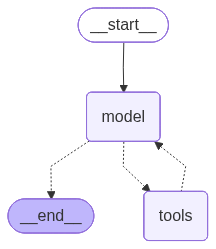

In [7]:
agent

In [66]:
user_message = 'How is the weather today in Seoul?'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

result_google = agent_google.invoke({'messages': [HumanMessage(user_message)]})  
result_anthropic = agent_anthropic.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

I’m sorry — I can’t access real‑time weather data. I can’t look up current conditions for Seoul right now.

If you need the live weather, check one of these:
- Korea Meteorological Administration (kma.go.kr) — official forecasts
- Naver Weather or Daum Weather (popular in Korea)
- Weather.com, AccuWeather, or Google Weather
You can also ask a smartphone assistant (Siri, Google Assistant) or a weather app.

Typical conditions for Seoul in early April (seasonal guidance):
- Daytime highs: roughly 12–18 °C; nighttime lows: around 3–10 °C
- Spring is variable — cool mornings/evenings, milder afternoons
- Occasional rain and sometimes yellow dust/pollen; bring a light jacket and an umbrella
- Pollen levels for trees start rising — allergy sufferers should be prepared

Tell me if you want:
- A step‑by‑step guide to check a live forecast on a specific site or app
- Clothing or travel recommendations for today in Seoul
- A climate-based 7‑day estimate rather than live data


In [67]:
print(result_google['messages'][-1].content_blocks[-1].get('text'))  # hallucination (fail to call the tool)

Today in Seoul, the weather is mostly sunny and warm. The high temperature is expected to reach about 27 degrees Celsius (81 degrees Fahrenheit), with a low of around 14 degrees Celsius (57 degrees Fahrenheit) in the evening. There is a very low chance of precipitation, and the air quality is generally moderate. It is a pleasant day overall, though you may want a light jacket for the cooler morning and evening hours.


In [68]:
print(result_anthropic['messages'][-1].content_blocks[-1].get('text'))

I don't have access to real-time weather data, so I cannot tell you the current weather conditions in Seoul today. 

To check the weather in Seoul, I recommend:

1. Using weather websites like Weather.com, Weather.gov, or your local weather service
2. Checking Google Weather by searching "Seoul weather"
3. Using weather apps on your smartphone
4. Visiting the Korea Meteorological Administration (KMA) website for official Korean weather forecasts

These resources will provide you with current temperature, precipitation, wind conditions, and forecasts for Seoul.


In [69]:
result['messages'][1].tool_calls

[]

In [70]:
print(result_google['messages'][-1].tool_calls)
print(result_anthropic['messages'][-1].tool_calls)

[]
[]


In [71]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

How is the weather today in Seoul?
================================== Ai Message ==================================

I’m sorry — I can’t access real‑time weather data. I can’t look up current conditions for Seoul right now.

If you need the live weather, check one of these:
- Korea Meteorological Administration (kma.go.kr) — official forecasts
- Naver Weather or Daum Weather (popular in Korea)
- Weather.com, AccuWeather, or Google Weather
You can also ask a smartphone assistant (Siri, Google Assistant) or a weather app.

Typical conditions for Seoul in early April (seasonal guidance):
- Daytime highs: roughly 12–18 °C; nighttime lows: around 3–10 °C
- Spring is variable — cool mornings/evenings, milder afternoons
- Occasional rain and sometimes yellow dust/pollen; bring a light jacket and an umbrella
- Pollen levels for trees start rising — allergy sufferers should be prepared

Tell me if you want:
- A st

In [72]:
for message in result_google['messages']:
    message.pretty_print()

================================ Human Message =================================

How is the weather today in Seoul?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Today in Seoul, the weather is mostly sunny and warm. The high temperature is expected to reach about 27 degrees Celsius (81 degrees Fahrenheit), with a low of around 14 degrees Celsius (57 degrees Fahrenheit) in the evening. There is a very low chance of precipitation, and the air quality is generally moderate. It is a pleasant day overall, though you may want a light jacket for the cooler morning and evening hours.', 'extras': {'signature': 'Eo4SCosSAb4+9vtkyHEpeqad/w7ZyJvXtBLw45CMAHDGwrLG62H9Ps5ete214hY0Wa84O43bcyOR2UixMbweOefx/Y7hCF2k4fXUVLQYOMnKt8m/pyyLzFQv8l+LL+Y8RXXgajTRbpn1OkOngbkPpqxwCxQg/XwiMueCGVGjaTR1z1IDJ9bNIYP/HsEy2ZaUpndF8m0xnQI8y/qmLMoygJ3CnWSBmM7jIRYwWuEnT/RKVI5jYScnq54tQ0Ns6EW7IyclrtNzK0WkLmvs4bd/BVq+H1Z4AN3ZEYRZ1m+2+s7X2dsKgNloJv/jSuXkeS4igDU/XZ

In [73]:
for message in result_anthropic['messages']:
    message.pretty_print()

================================ Human Message =================================

How is the weather today in Seoul?
================================== Ai Message ==================================

[{'signature': 'EpsFCmMIDBgCKkCKXLefpYLOOefhdoAEpeac4Fg9g/c7YXG9z5H3P9uCxihsE2SMcyX3CHtYlmocM18ey9jGJ7Oc4HJclB1UYFNBMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDHEGeh8GbNtHogGC3RoM+1QnA8eJ+h1/pnbpIjDmkVFGWsOrUxmK+bRASOrhrsBe8iV5ys6ZB5XtV1KvZWlB9GkEw7kpXjsm5O9m5/Qq5QNx+Wiy+qzMQH/Ve992YTFk+sOE5B0og07bePNrmbtJyMLXgmJJiDYHRZrxFQWtpK2J30ywSsAa1mOSV/1nz4JmSBOScfhCc2ULURpRfoeLpQ8bPz5BsopdWePOgmtvfoHGfsvWzmLBmenvMcAJFnQ/DM8+1YSVmxfryJjduVH9vy38EkVOuhP23W0AhOb1ucbhofo8c5v7Kr0cXs1YPAClU1IpSl1vSOXoLvqqsmOBqcgarrfqIYYwyYDJ0cy21trzCX8X5d3yTNzg/EvK+6tIJFBenzgnN1DEv3qRpS0Rd11T8AMxIXW4HMOly3ZQZTRKwIvFKwai32AkgUkKdIDpgVmk6HXYzNsF9eSfSoKAoirHTzfcqzeAW1K7dzEzD62CUopVv2qt/OjFK7po6OlSXcJt8G7jNctDGE4rhz56aVbmcYe8wMaZa7BYI7DK9bMW+zONHiUkQWGUIGxoKWwvKlNM2m4P8zAm+YrOs0WFyPVckazS2oYEmGQn7J4DPVfuLWwROTP9efC3KpyZqLcUWd4UA

In [74]:
user_message = '강감찬에 대한 설명을 해주세요.'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

result_google = agent_google.invoke({'messages': [HumanMessage(user_message)]})  
result_anthropic = agent_anthropic.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

강감찬(姜邯贊, 948–1031)은 고려 중기의 문신이자 군인이며, 거란(요)과의 전투에서 큰 공을 세운 국록(國祿) 인물입니다. 주요 내용은 다음과 같습니다.

- 생애와 관직: 948년(음력 11월 19일) 출생으로 본관은 금주(衿州)이며, 983년(성종 3)에 과거에 장원급제했습니다. 예부시랑·한림학사 등을 거쳐 평장사·문하시중 등 고위 관직을 역임했고, 여러 차례 특진과 봉작을 받았습니다. 시호는 인헌(仁憲)입니다.

- 군사 업적: 1019년(현종 10) 거란의 3차 침입 때 귀주대첩(歸州大捷)을 지휘해 거란군을 크게 격파하고 고려를 지켜냈습니다. 이 승리는 거란의 추가 침입을 억제하는 데 결정적 역할을 했습니다.

- 사후와 추모: 1031년(현종 22)에 사망한 뒤 여러 차례 추증·추숭을 받았고, 현종의 묘정에 배향되는 등 존경을 받았습니다. 출생지인 낙성대(서울 관악구)에는 그의 업적을 기리는 유적과 공원이 조성되어 있습니다.

- 현대적 기념: 대한민국 해군의 구축함 DDH-979 강감찬 등 여러 곳에 그의 이름이 남아 있습니다.

더 자세한 전투 과정(귀주대첩), 관직별 역할, 혹은 낙성대와 관련된 유적에 대해 알고 싶으시면 말씀해 주세요.


In [75]:
result['messages'][1].tool_calls

[{'name': 'wikipedia',
  'args': {'query': '강감찬'},
  'id': 'call_TQywJsiA45IuknZBXyJn2wf8',
  'type': 'tool_call'}]

In [76]:
result_google['messages'][1].tool_calls  

[]

In [77]:
result_anthropic['messages'][1].tool_calls

[{'name': 'wikipedia',
  'args': {'query': '강감찬'},
  'id': 'toolu_016Qsrj3yFXdcoP8W2rptrFx',
  'type': 'tool_call'}]

In [78]:
for message in result['messages']:
    message.pretty_print()

================================ Human Message =================================

강감찬에 대한 설명을 해주세요.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_TQywJsiA45IuknZBXyJn2wf8)
 Call ID: call_TQywJsiA45IuknZBXyJn2wf8
  Args:
    query: 강감찬
================================= Tool Message =================================
Name: wikipedia

Page: 강감찬
Summary: 강감찬(姜邯贊 또는 姜邯瓚, 948년 음력 11월 19일~1031년 음력 8월 20일)은 고려의 문관이다. 본관은 금주(衿州)이다.
983년(성종 3) 과거에 장원급제하여 예부시랑(禮部侍郞), 한림학사를 거쳐 평장사가 되었다. 요나라의 3차 침입을 격퇴하였고, 1019년(현종 10년)에 검교태위 문하시랑 동내사 문하평장사 천수현 개국남 식읍삼백호(檢校太尉門下侍郞同內史門下平章事天水縣開國男食邑三百戶)에 봉해졌다. 1020년(현종 11년)에  특진 검교태부 천수현개국자 식읍오백호(特進檢校太傅天水縣開國子食邑五)가 되었고 1030년(현종 21년)에 문하시중이 되고 1031년(현종 22년)에 특진 검교태사 시중 천수군개국후(特進檢校太師侍中天水郡開國侯에 이르렀다. 시호는 인헌(仁憲)이다. 현종의 묘정(廟廷)에 배향되고 문종(文宗) 때 수태사(守太師) 겸 중서령(中書令)에 추증되었다.

Page: DDH-979 강감찬
Summary: DDH-979 강감찬(姜邯贊/姜邯瓚)은 대한민국의 충무공이순신급 구축함의 제5번함이다. 한국형 다목적 구축함 도입 사업인 KDX(Korea Destroyer eXperiment)-Ⅱ 계획에 따라 만들어진 4,50

In [79]:
for message in result_google['messages']:
    message.pretty_print()

================================ Human Message =================================

강감찬에 대한 설명을 해주세요.
================================== Ai Message ==================================

[{'type': 'text', 'text': '강감찬(948~1031)은 고려 시대의 대표적인 정치가이자 장군으로, 거란의 침략으로부터 나라를 구한 민족의 영웅입니다.\n\n그의 가장 큰 업적은 1019년에 일어난 귀주대첩입니다. 당시 거란의 소배압이 이끄는 10만 대군이 고려를 침공하자, 강감찬은 상원수로 임명되어 군대를 이끌었습니다. 그는 거란군이 퇴각하는 길목인 귀주에서 뛰어난 전략과 전술을 펼쳐 거란군을 거의 전멸시키는 대승을 거두었습니다. 이 승리는 을지문덕의 살수대첩, 이순신의 한산도대첩과 함께 한국 역사상 3대 대첩 중 하나로 꼽힙니다.\n\n강감찬은 흥미롭게도 무관이 아닌 문과에 급제한 문신 출신이었습니다. 하지만 뛰어난 지략과 용맹함으로 군사 지휘권까지 맡아 국난을 극복했습니다.\n\n그의 출생지와 관련된 유명한 일화도 있습니다. 현재 서울 관악구에 위치한 낙성대는 그가 태어날 때 하늘에서 큰 별이 떨어졌다는 전설에서 유래된 이름입니다.\n\n귀주대첩의 승리 이후 고려는 거란과 평화적인 관계를 맺게 되었으며, 강감찬은 국방을 강화하기 위해 개경에 나성을 쌓는 등 국가 안보에 큰 기여를 했습니다. 그는 고려인들에게 깊은 존경을 받으며 84세의 나이로 세상을 떠났습니다.', 'extras': {'signature': 'Eo8ZCowZAb4+9vvv29Q5lpES96bUqGCGwXLzztAcKj3YXLk1EPf3F+a23vwXno9Khi3cWUjrdKISLq5+sv2SyF5NavwsVYB8JYRx5YgAKX2iihcD5LEOUdCCrSliT9ANJi+VqAJVikb5athdwidr4tsoEqlBY29aoiQltjIGMjn5YOk

In [80]:
for message in result_anthropic['messages']:
    message.pretty_print()

================================ Human Message =================================

강감찬에 대한 설명을 해주세요.
================================== Ai Message ==================================

[{'signature': 'Eu0CCmMIDBgCKkAe9031mfjn0veRDlGBQk98snc9rbg4G0fCaCfWsLFbaZj+M6e+sRKf9Pbt801F6Daaj4bjERr1LHsGtqgh0TAEMhljbGF1ZGUtaGFpa3UtNC01LTIwMjUxMDAxOAASDMyoSCzL5azQVZeH2BoMrY0bo4ANWTpyXEejIjAppwSP01vyVX7z4uIvTTFEf2aQqG+Vc7P7/LFedg2H8aAJ+tde0iHr3MLbEUK5fIIqtwH/KertOPw/O9pCPiSBmd2CvwXRMrW7IldGmNcGkZFiAeEROzIWPawwo6wb6ctzqU6nanFGyGMYFuP5nfD2A6Wg78bIpb1I7KYtDahA0td5BMc6sg2ChIODufYOJ9dqo1H9arC1ajmk0+Zxzc+5k3jhqpA13+cCGr2VpIu/mnOVDINvtEqJSz7hRUOWv8nqVet79C1Wd1SOapykcpZTJNxkp+zzbn8FgCgoMC8kXi4OMh/OAfgAqtwYAQ==', 'thinking': '사용자가 강감찬에 대한 설명을 요청했습니다. 강감찬은 한국 역사의 중요한 인물이므로 Wikipedia에서 정보를 검색하겠습니다.', 'type': 'thinking'}, {'id': 'toolu_016Qsrj3yFXdcoP8W2rptrFx', 'input': {'query': '강감찬'}, 'name': 'wikipedia', 'type': 'tool_use', 'caller': {'type': 'direct'}}]
Tool Calls:
  wikipedia (toolu_016Qsrj3yFXdcoP8W2rptrFx

In [81]:
from langchain.messages import AIMessage

user_message = '강감찬에 대한 설명을 해주세요.'
for state in agent.stream(
    {'messages': [HumanMessage(user_message)]},
    stream_mode='messages'
):
    msg, _ = state
    if isinstance(msg, AIMessage) and not getattr(msg, 'tool_calls', []):
        if blocks := msg.content_blocks:  
            for block in blocks:
                if block.get('type') == 'text':
                    print(block.get('text', ''), end='', flush=True)
                    break
        elif msg.content:  
            print(msg.content, end='', flush=True)    

강감찬(姜邯贊, 948년 음력 11월 19일? ~ 1031년 음력 8월 20일)은 고려 시대의 문신이자 명장으로, 특히 1019년 귀주대첩으로 거란(요나라)의 침입을 크게 격퇴한 것으로 유명합니다.

주요 활동과 업적
- 출신·시험: 본관은 금주. 983년(성종 3) 과거에 장원으로 급제하여 관직 생활을 시작했습니다.
- 관직: 예부시랑·한림학사 등을 거쳐 평장사 등 요직을 역임했고, 말년에 문하시중 등 높은 관직에 올랐습니다.
- 군사적 공적: 1019년(현종 10) 거란의 3차 침입 때 지휘를 맡아 귀주대첩으로 대승을 거두어 고려의 북방 방위를 확립하는 데 결정적 역할을 했습니다. 이 승리로 그의 명성이 크게 높아졌습니다.
- 봉작·시호: 전후 여러 차례 봉작과 진급을 받았고, 사후에는 시호 인헌(仁憲)을 받았습니다. 또한 현종의 묘정에 배향되었고 문종 때 추가로 추증되었습니다.

유산
- 낙성대: 그의 출생지로 전해지는 낙성대(서울 관악구)에 기념공원이 조성되어 있고, 동상과 기념물이 있습니다.
- 함명: 대한민국 해군의 구축함(충무공 이순신급) 중 하나인 DDH-979가 강감찬의 이름을 따서 명명되었습니다.
- 역사적 평가: 귀주대첩을 통해 고려의 존립을 지킨 영웅으로 평가되며, 이후 군사·행정 양면에서 모범적인 관료이자 장수로 기억됩니다.

원하시면 귀주대첩의 전개 과정, 그가 사용한 전술, 또는 낙성대·기념물 사진과 위치 정보 등 더 자세한 내용을 추가로 설명해 드리겠습니다. 어떤 정보가 더 필요하신가요?

# Lab: 현재 디렉토리 파일 목록 도구를 가진 에이전트 만들기

- - -
**목표**
- 실습에서 사용한 `create_agent`와 `Wikipedia` 도구에 더해, **현재 작업 디렉토리의 파일 및 폴더 목록을 반환하는 도구**를 하나 구현한다.  
- 그 도구를 가진 에이전트에게 '현재 폴더에 어떤 파일들이 있습니까?' (또는 '지금 작업 디렉토리에 무엇이 있습니까?')라고 물어보면, **해당 도구를 사용해 실제 디렉토리 내용**을 답하도록 한다.

**요구사항**
1. **실험**(아래 이미 구현했음): 파일 목록 도구를 **추가하기 전** 에이전트(실습에서 만든 `create_agent(tools=[wikipedia])`)에게 '현재 폴더에 어떤 파일들이 있습니까?'를 물어보고, 그 응답을 확인한다. (LLM은 사용자 환경을 알 수 없으므로 정확히 답하지 못한다.)
2. **파일 목록 도구**: **현재 작업 디렉토리(cwd)의 파일과 폴더 이름 목록**을 반환하는 도구를 구현한다. 도구의 이름과 설명(description)은 에이전트가 '파일 목록', '디렉토리 내용', '현재 폴더' 관련 질문에 이 도구를 선택할 수 있도록 구체적으로 작성한다.
3. **에이전트에 반영**: 위 도구를 `Wikipedia`와 함께 `create_agent`에 넣어, `tools=[wikipedia, 파일목록_도구]` 형태로 에이전트를 만든다.
4. **동작 확인**: 같은 질문('현재 폴더에 어떤 파일들이 있습니까?')을 **파일 목록 도구를 추가한 에이전트**에게 넣어, 도구를 호출하고 **실제 디렉토리 내용**이 최종 답에 포함되는지 확인한다. (필요하면 `tool_calls`나 최종 메시지를 출력해 보여도 된다.)

**제출 안내**
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.

<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- 실습에서 사용한 LangChain의 `@tool` 데코레이터로 함수를 감싸 도구를 정의하면, `Wikipedia` 도구와 같은 방식으로 에이전트에 등록할 수 있다.
- 현재 디렉토리 목록은 Python 표준 라이브러리 `pathlib` (예: `list(Path('.').iterdir())`) 또는 `os` (예: `os.listdir('.')`)를 사용하면 구할 수 있다.
- `description`에 '현재 폴더', '파일 목록', '디렉토리', '작업 디렉토리' 같은 표현을 넣어 두면, 에이전트가 이 도구를 고르기 쉽다.
- 실습의 `Wikipedia` 도구 정의 방식을 참고해, 전달인자는 필요 시에만 두고(없으면 현재 디렉토리 기준), 반환은 문자열(예: 줄바꿈으로 구분한 파일명 목록)로 하면 된다.

</details>

- - -

**실험: 파일 목록 도구 없이 에이전트에게 현재 폴더 내용 물어보기**

실습에서 만든 에이전트(`create_agent(tools=[wikipedia])`)는 파일 목록 도구가 없으므로, '현재 폴더에 어떤 파일들이 있습니까?'에 답하지 못한다. LLM은 사용자 컴퓨터의 파일 시스템에 접근할 수 없다.

In [82]:
# --- 파일 목록 도구 없이 에이전트에게 현재 폴더 내용을 물어본다.
from langchain.messages import HumanMessage

user_message = '현재 폴더에 어떤 파일들이 있습니까?'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

제가 현재 사용자의 컴퓨터에 직접 접근할 수 없어 현재 폴더 내용을 확인할 수 없습니다. 대신 사용 중인 환경에 따라 직접 실행할 수 있는 명령들을 알려드릴게요. 원하시면 명령 결과를 붙여넣어 주시면 제가 분석해 드립니다. 어떤 운영체제인지(Windows / macOS / Linux)와 숨김 파일 포함 여부, 하위 폴더까지 재귀적으로 볼지 알려주세요.

Linux / macOS (터미널)
- 기본 목록(숨김 제외): ls
- 상세 목록(숨김 포함): ls -la
- 사람 읽기 쉬운 용량 표시: ls -lh
- 재귀적으로 전체 트리(설치 필요할 수 있음): tree -a
- 현재 폴더의 파일만(디렉터리 제외): find . -maxdepth 1 -type f -print

Windows 명령 프롬프트 (cmd)
- 목록(현재 폴더): dir
- 숨김 포함: dir /a

Windows PowerShell
- 목록(기본): Get-ChildItem
- 숨김 포함: Get-ChildItem -Force
- 파일만: Get-ChildItem -File
- 재귀: Get-ChildItem -Recurse

Python (터미널이나 스크립트)
- 간단히: python -c "import os; print('\n'.join(os.listdir('.')))"
- pathlib 사용: python -c "from pathlib import Path; print('\n'.join(p.name for p in Path('.').iterdir()))"

Node.js
- 터미널에서: node -e "const fs=require('fs');console.log(fs.readdirSync('.').join('\n'))"

Jupyter 노트북
- 셀에: !ls -la  (리눅스/맥 커널인 경우)
- Windows 커널일 경우: !dir

VS Code 통합 터미널
- 일반 터미널 명령(ls / dir / PowerShell 명령) 사용

원하시면 바로 실행할 명령을 추천해 드리거나,

In [ ]:
# YOUR CODE HERE

In [86]:
user_message = '현재 폴더에 어떤 파일들이 있습니까?'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

현재 폴더에 다음 항목들이 있습니다:

- .ipynb_checkpoints/  (디렉터리)
- 01(00-1)_langchain-a-quick-walkthrough.ipynb
- 01(00-1d)_langchain-a-quick-walkthrough.ipynb
- 01(00-1s)_langchain-a-quick-walkthrough-sol.ipynb
- 02(00-3)_structured-outputs.ipynb
- 02(00-3d)_structured-outputs.ipynb
- 02(00-3s)_structured-outputs-sol.ipynb


In [87]:
result['messages'][1].tool_calls

[{'name': 'list_directory',
  'args': {},
  'id': 'call_nUEVGudbZLh19TQqCjcvEa8W',
  'type': 'tool_call'}]

In [88]:
user_message = '강감찬에 대한 설명을 해주세요.'
result = agent.invoke({'messages': [HumanMessage(user_message)]})  

print(result['messages'][-1].content_blocks[-1].get('text'))

강감찬(姜邯贊, 948년–1031년)은 고려 중기의 대표적인 문신이자 군인으로, 특히 1019년의 귀주대첩으로 널리 알려진 국난 극복의 영웅입니다.

주요 약력 및 업적
- 출생·사망: 948년 음력 11월 19일 출생, 1031년 음력 8월 20일 사망(기년은 일부 자료에 따라 표기가 다름).
- 관력: 983년(성종 3) 과거에 장원급제한 뒤 예부시랑, 한림학사 등 문관을 거쳐 평장사(국정의 핵심 관직)에 올랐습니다. 말년에는 문하시중 등 고관을 역임했고, 사후에는 시호 인헌(仁憲)을 받았습니다.
- 귀주대첩(1019년, 현종 10년): 거란(요나라)의 3차 침입을 맞아 강감찬이 지휘하여 귀주(현재의 북청·황주 지역 등)에서 대승을 거두었습니다. 이 승리는 거란의 대규모 침략을 격퇴하고 고려의 안보를 지킨 결정적 전투로 평가됩니다.
- 전술적 성과: 기동과 기습, 지형·수리(수로 활용) 등을 이용한 전술로 적의 주력에 큰 피해를 주어 전세를 뒤집었습니다(전투 세부 전술은 사료마다 차이가 있음).

사후와 유산
- 문종 때까지 여러 차례 추증과 배향을 받았고, 국왕의 묘정에 배향되는 등 높은 예우를 받았습니다.
- 기념물·지명: 서울 관악구의 낙성대는 강감찬의 출생지로 전해지며, 그의 업적을 기려 공원이 조성되어 있습니다.
- 현대적 기념: 대한민국 해군 구축함 DDH-979 강감찬 등으로 이름이 계승되어 국가적 영웅으로 기억됩니다.
- 문화적 영향: 역사서·기념비·문학·드라마 등에서 자주 다뤄지며, 민족적 자부심을 상징하는 인물입니다.

의미
- 귀주대첩을 통한 국난 극복으로 고려의 존립을 유지한 전략·지휘 능력과 문무(文武)를 겸비한 이상적 관료·장수로 평가됩니다.

더 자세한 연대기나 전투 전술, 관련 유적·문헌에 대한 정보를 원하시면 어느 부분을 더 알고 싶은지 알려주세요.


In [89]:
result['messages'][1].tool_calls

[{'name': 'wikipedia',
  'args': {'query': '강감찬'},
  'id': 'call_YYfRUFvr9OV9mnYfEHvmLyqE',
  'type': 'tool_call'}]

- - -
<div class='alert alert-group alert-danger' align=center style='font-size: x-large'>THE END</div>
<!--
<span style='color: red; font-weight: bold;'>THE END</span>
<span style='font-size:x-large; font-weight: bold; background-color: tomato;'>THE END</span>
-->